Seperating the known and unknown associations..
Staring the clustering based sampling for unknown i.e. negative associations
Final datasets are being prepared now..
Total number of samples in the final dataset for training: 906
GBDTSVM classifier running...
ROC AUC: 0.9626811594202899
Score: 0.8846153846153846
ROC AUC: 0.9277777777777778
Score: 0.8729281767955801
ROC AUC: 0.9719711773326819
Score: 0.9171270718232044
ROC AUC: 0.9785661944308743
Score: 0.9337016574585635
ROC AUC: 0.9612848070346849
Score: 0.9116022099447514
Final F1 Score: 0.9148936170212766


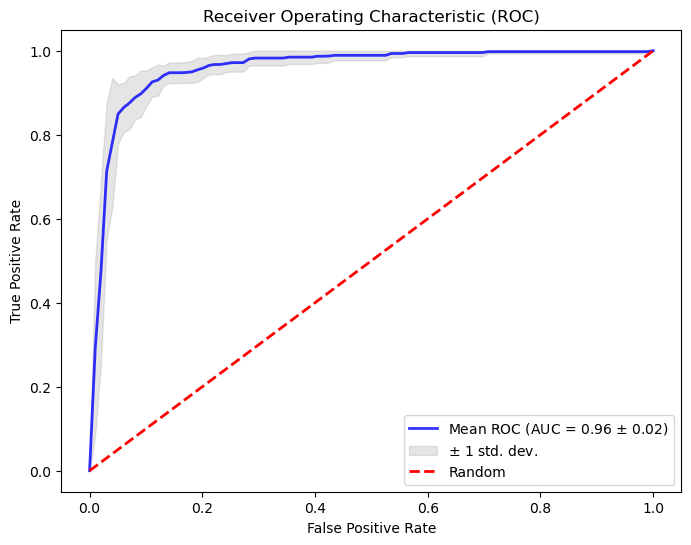

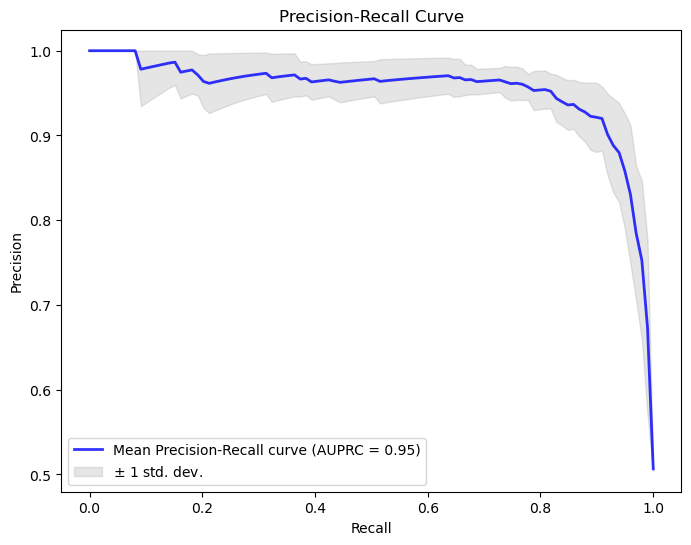

In [1]:
import random
import numpy as np
import pandas as pd
import os
from matplotlib import pyplot as plt
from numpy import interp
from sklearn.cluster import KMeans
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import OneHotEncoder
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import precision_recall_curve, roc_curve, auc, confusion_matrix, accuracy_score, classification_report
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score


# Define input and output directories
input_data_dir = "PSnoD"
Dataset = "PSnoD"
disease = pd.read_csv(os.path.join(input_data_dir, 'disease_sim_graph_filtered.csv'))
snoRNA = pd.read_csv(os.path.join(input_data_dir, 'snoRNA_4mer_similarity.csv'))
relation = pd.read_csv(os.path.join(input_data_dir, 'relationship_matrix_filtered.csv'))


disease_name = disease.iloc[:,0:1]
snoRNA_name = snoRNA.iloc[:,0:1]
SnoRNA_similarity = snoRNA.iloc[:,1:]
known_association = relation.iloc[:, 1:].T
disease_similarity = disease.iloc[:,1:]


disease_semantic_similarity = np.zeros(disease_similarity.shape) 
snoRNA_functional_similarity = np.zeros(SnoRNA_similarity.shape) 
adjacency_matrix = np.zeros(known_association.shape) 


disease_semantic_similarity = disease_similarity.values
snoRNA_functional_similarity = SnoRNA_similarity.values
adjacency_matrix = known_association.values


print("Seperating the known and unknown associations..")


unknown = []
known = []
for x in range(known_association.shape[0]):
    for y in range(known_association.shape[1]):
        if adjacency_matrix[x, y] == 0:
            unknown.append((x, y))
        else:
            known.append((x, y))


major = []


for z in range(len(unknown)):
    a = disease_semantic_similarity[unknown[z][1], :].tolist()
    b = snoRNA_functional_similarity[unknown[z][0], :].tolist()
    q = a + b
    major.append(q)

print("Staring the clustering based sampling for unknown i.e. negative associations")
kmeans = KMeans(n_clusters=23, random_state=0).fit(major)
center = kmeans.cluster_centers_
labels = kmeans.labels_ # label is given to all the datapoints but within 1 to 20


# we have seperated x and y of each centre pair.
center_x = []
center_y = []
for j in range(len(center)):
    center_x.append(center[j][0])
    center_y.append(center[j][1])

disease_rna_tup = [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]
for i in range(len(labels)):
    if labels[i] == 0:
        disease_rna_tup[0].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 1:
        disease_rna_tup[1].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 2:
        disease_rna_tup[2].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 3:
        disease_rna_tup[3].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 4:
        disease_rna_tup[4].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 5:
        disease_rna_tup[5].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 6:
        disease_rna_tup[6].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 7:
        disease_rna_tup[7].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 8:
        disease_rna_tup[8].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 9:
        disease_rna_tup[9].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 10:
        disease_rna_tup[10].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 11:
        disease_rna_tup[11].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 12:
        disease_rna_tup[12].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 13:
        disease_rna_tup[13].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 14:
        disease_rna_tup[14].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 15:
        disease_rna_tup[15].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 16:
        disease_rna_tup[16].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 17:
        disease_rna_tup[17].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 18:
        disease_rna_tup[18].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 19:
        disease_rna_tup[19].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 20:
        disease_rna_tup[20].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 21:
        disease_rna_tup[21].append((unknown[i][0], unknown[i][1]))
    elif labels[i] == 22:
        disease_rna_tup[22].append((unknown[i][0], unknown[i][1]))


print("Final datasets are being prepared now..")
sampled_disease_rna_tup = [[], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], [], []]
for i in range(len(disease_rna_tup)):
    # print(int((len(disease_rna_tup[i])/len(labels)) * len(known)))
    sampled_disease_rna_tup[i] = random.sample(disease_rna_tup[i], int((len(disease_rna_tup[i])/len(labels)) * len(known)))


dataset = []
for rna in range(known_association.shape[0]):
    # print(f"rna val:{rna}")
    for disease in range(known_association.shape[1]):
        # print(f"disease val:{disease}")
        for i in range(len(sampled_disease_rna_tup)):
            if (rna, disease) in sampled_disease_rna_tup[i]:
                dataset.append((rna, disease))


for rna in range(known_association.shape[0]):
    for disease in range(known_association.shape[1]):
        if (rna, disease) in known:
            dataset.append((rna, disease))


length = len(dataset)
print(f"Total number of samples in the final dataset for training: {length}")
selected_x = []
selected_y = []
#now I am just taking only the similarities of disease and rna of sampled data.
for data in dataset:
    a = disease_semantic_similarity[data[1], :].tolist()
    b = snoRNA_functional_similarity[data[0], :].tolist()
    q = a + b
    selected_x.append(q)

    if (data[0], data[1]) in known:
        selected_y.append(1)
    else:
        selected_y.append(0)

selected_data_np = np.array(selected_x)
selected_label_np = np.array(selected_y)



## Data prepation ends here before training the model--------------------------------

print("GBDTSVM classifier running...")
#### Gradient Boosting Classifier--------------------------------

GBDT=GradientBoostingClassifier(n_estimators = 12,max_depth=5,min_samples_leaf=13)
GBDT.fit(selected_data_np, selected_label_np)
OHE = OneHotEncoder()
OHE.fit(GBDT.apply(selected_data_np)[:, :, 0])


tprs = []
aucs = []
mean_fpr = np.linspace(0,1,100)


SVM = svm.SVC(kernel='rbf', probability=True)

# Create a pipeline that scales the data-snoRNA-disease and then applies SVM
pipeline = Pipeline([('scaler', StandardScaler(with_mean=False)), ('SVM', SVM)])
# Define the parameter grid for C and gamma
param_grid = {'SVM__C': [0.1, 1, 10, 100], 'SVM__gamma': [1, 0.1, 0.01, 0.001]}

# Use GridSearchCV to find the optimal parameters
grid = GridSearchCV(pipeline, param_grid, cv=5)

# # Train the classifier
# using 5 fold cross validation:

stratified_k_fold = StratifiedKFold(n_splits=5)
# Initialize lists to store predicted and actual values
tprs = []
aucs = []
mean_fpr = np.linspace(0, 1, 100)
precisions = []
recalls = []
roc_auc_scores = []
scores = []
mean_recall = np.linspace(0, 1, 100)
y_true = []
y_pred = []

for train_index, test_index in stratified_k_fold.split(selected_data_np, selected_label_np):
    # Split the data into training and test sets
    X_train, X_test = selected_data_np[train_index], selected_data_np[test_index]
    y_train, y_test = selected_label_np[train_index], selected_label_np[test_index]

    grid.fit(OHE.transform(GBDT.apply(X_train)[:, :, 0]), y_train)   # Train the classifier

    predicted_probs = grid.predict_proba(OHE.transform(GBDT.apply(X_test)[:, :, 0]))[:, 1]  # Make predictions on the test set using the best parameters

    roc_auc = roc_auc_score(y_test, predicted_probs)  # Calculate the ROC AUC score and append it to the list
    print('ROC AUC:', roc_auc)
    roc_auc_scores.append(roc_auc)


    score = grid.score(OHE.transform(GBDT.apply(X_test)[:, :, 0]), y_test)  # Calculate the score and append it to the list
    print('Score:', score)
    scores.append(score)


    fpr, tpr, thresholds = roc_curve(y_test, predicted_probs)   # Compute ROC curve and area under the curve
    tprs.append(interp(mean_fpr, fpr, tpr))
    tprs[-1][0] = 0.0
    roc_auc = auc(fpr, tpr)
    aucs.append(roc_auc)


    precision, recall, _ = precision_recall_curve(y_test, predicted_probs)  # Compute Precision-Recall curve
    precisions.append(interp(mean_recall, recall[::-1], precision[::-1]))

    y_true.extend(y_test)
    predicted = grid.predict(OHE.transform(GBDT.apply(X_test)[:, :, 0]))
    y_pred.extend(predicted)


f1 = f1_score(y_test, predicted)
print("Final F1 Score:", f1)


# Plotting ROC curve
plt.figure(figsize=(8, 6))
mean_tpr = np.mean(tprs, axis=0)
mean_tpr[-1] = 1.0
mean_auc = auc(mean_fpr, mean_tpr)
std_auc = np.std(aucs)
plt.plot(mean_fpr, mean_tpr, color='b', label=r'Mean ROC (AUC = %0.2f $\pm$ %0.2f)' % (mean_auc, std_auc), lw=2, alpha=.8)
std_tpr = np.std(tprs, axis=0)
tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
tprs_lower = np.maximum(mean_tpr - std_tpr, 0)
plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend()
plt.show()


# Plotting PRC curve
plt.figure(figsize=(8, 6))
mean_precision = np.mean(precisions, axis=0)
mean_precision[0] = 1.0
mean_auc_pr = auc(mean_recall, mean_precision)
plt.plot(mean_recall, mean_precision, color='b', label='Mean Precision-Recall curve (AUPRC = {:.2f})'.format(mean_auc_pr), lw=2, alpha=.8)
std_precision = np.std(precisions, axis=0)
precisions_upper = np.minimum(mean_precision + std_precision, 1)
precisions_lower = np.maximum(mean_precision - std_precision, 0)
plt.fill_between(mean_recall, precisions_lower, precisions_upper, color='grey', alpha=.2, label=r'$\pm$ 1 std. dev.')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.show()


Seperating the known and unknown associations..
Staring the clustering based sampling for unknown i.e. negative associations
Final datasets are being prepared now..
Total number of samples in the final dataset for training: 906
GBDTSVM classifier running...
ROC AUC: 0.9657004830917875
Score: 0.9010989010989011
ROC AUC: 0.9604395604395605
Score: 0.9060773480662984
ROC AUC: 0.9523693209574988
Score: 0.8895027624309392
ROC AUC: 0.9753297508549096
Score: 0.9337016574585635
ROC AUC: 0.9683072789447973
Score: 0.9005524861878453
Final F1 Score: 0.9010989010989011


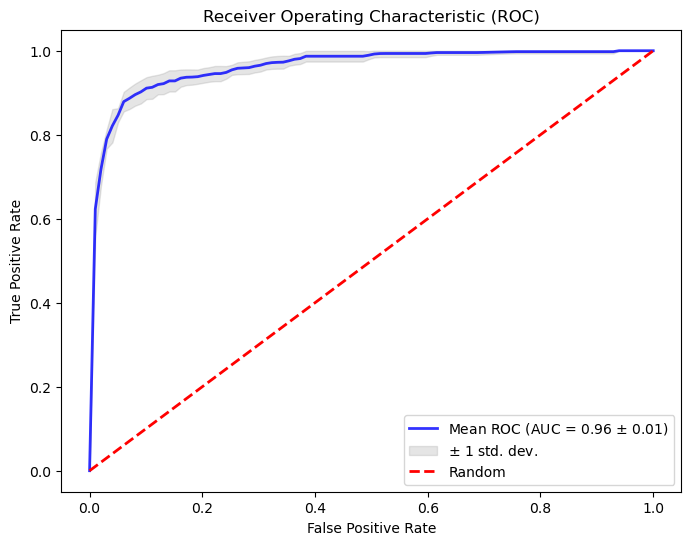

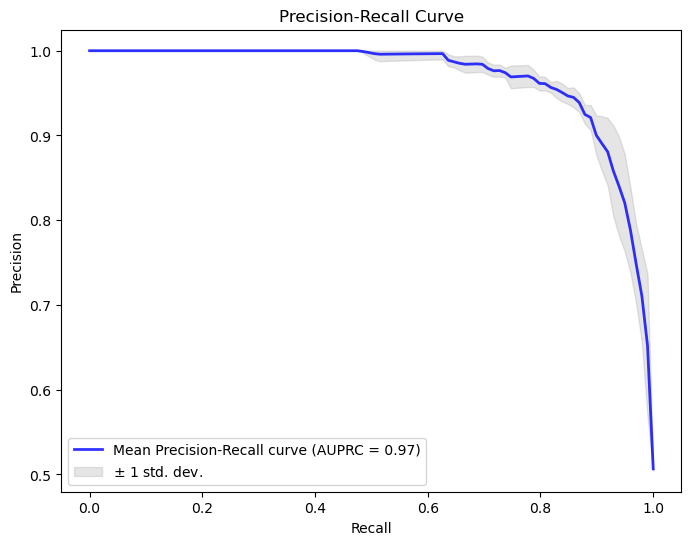

GBDTSVM Classifier training ends..
Predictions for unknown association now started
Unknown association between the snoRNA-disease pairs are predicted and save in the output files successfully, saved in: results


In [ ]:

print("GBDTSVM Classifier training ends..")
print("Predictions for unknown association now started")
# Now predicting associations for all unknown pairs
unknown_pair = []

for data in unknown:
    a1 = disease_semantic_similarity[data[1], :].tolist()
    b1 = snoRNA_functional_similarity[data[0], :].tolist()
    q1 = a1 + b1
    unknown_pair.append(q1)



#so far we have used certain number of samples from all the clustered unknown pairs, but now will predict for all the unknown pairs whether they have association or not
# here x1 contains the concatanated semantic similarity of diseases and functional similarity of snoRNAs of all unknown pairs

predicted_probabilities_all_unknowns = grid.predict_proba(OHE.transform(GBDT.apply(unknown_pair)[:, :, 0]))
unknown_pair_true_class = predicted_probabilities_all_unknowns[:, 1].tolist()

# here I have sorted the true class of all unknown pairs in descending order.
unknown_pair_true_class_np = np.array(unknown_pair_true_class)
sorted_probabilities = -np.sort(-unknown_pair_true_class_np, axis=None, kind='heapsort')


unknown_pair_true_class_matrix = np.matrix(unknown_pair_true_class)
sorted_class_index = np.argsort(-unknown_pair_true_class_matrix).tolist()
# print(len(sorted_class_index))
sorted_class_index = sorted_class_index[0]
# print(len(sorted_class_index))

# Write unknown true results to a text file
# file_unknown_true_path = os.path.join(output_dir, "unknown_true_svm.txt")
# with open(file_unknown_true_path, 'w') as file_unknown_true:
#     file_unknown_true.writelines(['disease', '\t', 'SnoRNA', '\t', 'Score', '\n'])
#     for i in range(len(sorted_class_index)):
#         file_unknown_true.writelines([
#             str(unknown[sorted_class_index[i]][1]), '\t',
#             str(unknown[sorted_class_index[i]][0]), '\t',
#             str(unknown_pair_true_class[sorted_class_index[i]]), '\n'
#         ])

# # Convert unknown_true_svm.txt into a CSV file
# file_unknown_true_csv_path = os.path.join(output_dir, "unknown_true_svm.csv")
# df = pd.read_csv(file_unknown_true_path, delimiter='\t')
# df.to_csv(file_unknown_true_csv_path, index=False)

# # Create another CSV file where only rows with Score >= 0.75 are stored
# file_unknown_true_75_csv_path = os.path.join(output_dir, "unknown_true_75_svm.csv")
# df = pd.read_csv(file_unknown_true_csv_path)
# df['Score'] = df['Score'].astype(float)
# df = df[df['Score'] >= 0.75]
# df.to_csv(file_unknown_true_75_csv_path, index=False)

# print(f"Unknown association between the snoRNA-disease pairs are predicted and save in the output files successfully, saved in: {output_dir}")